<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/ml/04-classification-models/svm/Project_02_SVM_Multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
import pandas as pd
from IPython import display
import seaborn as sns

# Getting a dataset from seaborn

In [26]:
iris = sns.load_dataset('iris')
iris.shape

(150, 5)

In [27]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris.species.unique()

# Display Flowers

In [ ]:
# The Iris Setosa
from IPython.display import Image
url = 'http://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg'
Image(url,width=300, height=300)

In [ ]:
# The Iris Versicolor
from IPython.display import Image
url = 'http://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg'
Image(url,width=300, height=300)

In [ ]:
# The Iris Virginica
from IPython.display import Image
url = 'http://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg'
Image(url,width=300, height=300)

# Transforming Labels to integers

In [ ]:
iris.species.replace(to_replace = 'setosa', value = 0, inplace = True)
iris.species.replace(to_replace = 'versicolor', value = 1, inplace = True)
iris.species.replace(to_replace = 'virginica', value = 2, inplace = True)

In [28]:
iris['species']=iris['species'].map({'setosa':0,'versicolor':1,'virginica':2})

In [29]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [30]:
iris['species'].value_counts()

,count
species,
0,50
1,50
2,50


# Extracting features and labels

In [31]:
X = iris.iloc[:,:-1].values

In [32]:
y = iris.iloc[:,-1].values


# Performing a train test split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [34]:
X_test.shape

(30, 4)

# Standardizing the data

In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Applying Support Vector Classifier

In [36]:
svc = SVC(kernel = 'rbf', C = 1, gamma = 'scale')
svc.fit(X_train, y_train)

SVC(C=1)

# Getting Predictions from X_test

In [37]:
y_pred = svc.predict(X_test)

In [38]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [39]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [40]:
y_pred == y_test

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

# Calculating Accuracy

In [41]:
Accuracy = np.mean(y_pred == y_test) * 100
print("Accuracy : %2.2f" % (Accuracy))

Accuracy : 100.00


# Generating Confusion Matrix

In [42]:
font = {
    'weight' : 'bold',
    'size'   : 15}
plt.rc('font', **font)

In [43]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

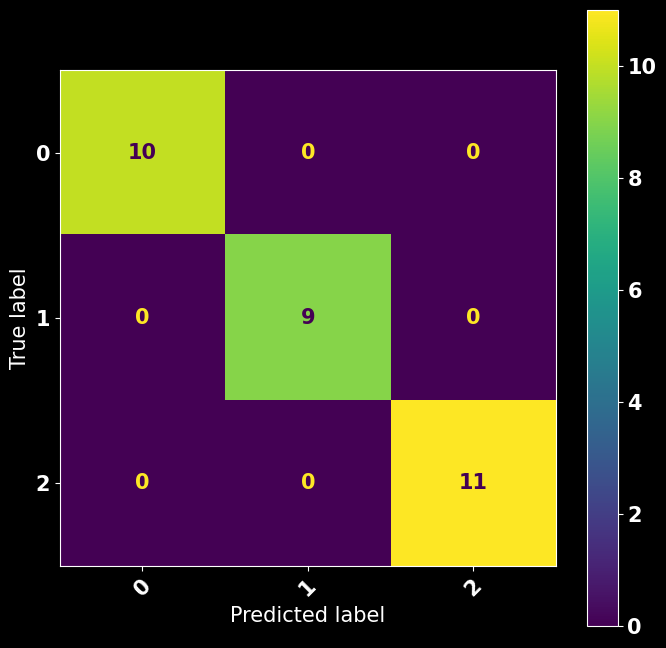

In [44]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= [0, 1, 2])
disp.plot(xticks_rotation=45)
fig = disp.ax_.get_figure()
fig.set_figwidth(8)
fig.set_figheight(8)
plt.show()

# Calculating Accuracy, Precision, Recall and F1-Score

In [45]:
Metrics = pd.DataFrame({"Accuracy":[accuracy_score(y_test, y_pred, normalize=True)]
,"Precision":[precision_score(y_test, y_pred, average = 'macro')]
,"Recall":[recall_score(y_test, y_pred, average = 'macro')]
,"F1-Score":[f1_score(y_test, y_pred, average = 'macro')]})


In [46]:
Metrics

,Accuracy,Precision,Recall,F1-Score
0,1.0,1.0,1.0,1.0
